In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Imports successful ✅")

Imports successful ✅


In [2]:
COLUMNS = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label",
    "difficulty"
]

print("Number of columns:", len(COLUMNS))

Number of columns: 43


In [3]:
DATA_DIR = Path("../data/raw")

TRAIN_PATH = DATA_DIR / "KDDTrain+.txt"
TEST_PATH = DATA_DIR / "KDDTest+.txt"

print("Train exists:", TRAIN_PATH.exists())
print("Test exists:", TEST_PATH.exists())

train_df = pd.read_csv(
    TRAIN_PATH,
    names=COLUMNS
)

test_df = pd.read_csv(
    TEST_PATH,
    names=COLUMNS
)

print("\nTraining shape:", train_df.shape)
print("Testing shape :", test_df.shape)

Train exists: True
Test exists: True

Training shape: (125973, 43)
Testing shape : (22544, 43)


In [4]:
pd.set_option("display.max_columns", None)

train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [5]:
train_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [6]:
train_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
duration,125973.0,NaN,NaN,NaN,287.14465,2604.51531,0.0,0.0,0.0,0.0,42908.0
protocol_type,125973,3,tcp,102689,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service,125973,70,http,40338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flag,125973,11,SF,74945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
src_bytes,125973.0,NaN,NaN,NaN,45566.743,5870331.181894,0.0,0.0,44.0,276.0,1379963888.0
dst_bytes,125973.0,NaN,NaN,NaN,19779.114421,4021269.151441,0.0,0.0,0.0,516.0,1309937401.0
land,125973.0,NaN,NaN,NaN,0.000198,0.014086,0.0,0.0,0.0,0.0,1.0
wrong_fragment,125973.0,NaN,NaN,NaN,0.022687,0.25353,0.0,0.0,0.0,0.0,3.0
urgent,125973.0,NaN,NaN,NaN,0.000111,0.014366,0.0,0.0,0.0,0.0,3.0
hot,125973.0,NaN,NaN,NaN,0.204409,2.149968,0.0,0.0,0.0,0.0,77.0


In [7]:
print("Training labels:")
print(train_df["label"].value_counts())

print("\nNumber of unique labels:")
print(train_df["label"].nunique())

Training labels:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

Number of unique labels:
23


In [23]:
missing = train_df.isnull().sum()

print("Columns with missing values:")
print(missing[missing > 0])

print("\nTotal missing values:", missing.sum())
print("Test missing values:", test_df.isnull().sum().sum())

Columns with missing values:
Series([], dtype: int64)

Total missing values: 0
Test missing values: 0


In [12]:
print("Training duplicates:", train_df.duplicated().sum())
print("Testing duplicates :", test_df.duplicated().sum())

Training duplicates: 0
Testing duplicates : 0


In [13]:
categorical_features = [
    "protocol_type",
    "service",
    "flag"
]

target_column = "label"
difficulty_column = "difficulty"

feature_columns = [
    col for col in COLUMNS
    if col not in [target_column, difficulty_column]
]

numerical_features = [
    col for col in feature_columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumber of numerical features:")
print(len(numerical_features))

print("\nTotal model features:")
print(len(feature_columns))

Categorical features:
['protocol_type', 'service', 'flag']

Number of numerical features:
38

Total model features:
41


In [14]:
train_df["target"] = (
    train_df["label"]
    .str.strip()
    .str.lower()
    .ne("normal")
    .astype(int)
)

test_df["target"] = (
    test_df["label"]
    .str.strip()
    .str.lower()
    .ne("normal")
    .astype(int)
)

print("Training target distribution:")
print(train_df["target"].value_counts())

print("\nTesting target distribution:")
print(test_df["target"].value_counts())

Training target distribution:
target
0    67343
1    58630
Name: count, dtype: int64

Testing target distribution:
target
1    12833
0     9711
Name: count, dtype: int64


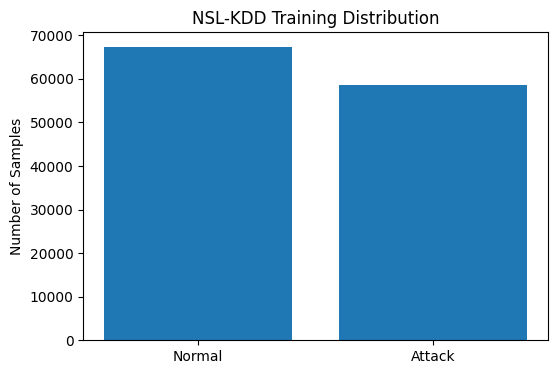

In [15]:
counts = train_df["target"].value_counts().sort_index()

plt.figure(figsize=(6, 4))

plt.bar(
    ["Normal", "Attack"],
    counts.values
)

plt.title("NSL-KDD Training Distribution")
plt.ylabel("Number of Samples")

plt.show()

In [16]:
X_train = train_df[feature_columns]
y_train = train_df["target"]

X_test = test_df[feature_columns]
y_test = test_df["target"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (125973, 41)
y_train: (125973,)
X_test : (22544, 41)
y_test : (22544,)


In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", classifier)
])

print("Model pipeline created ✅")

Model pipeline created ✅


In [18]:
print("Training model...")

model.fit(
    X_train,
    y_train
)

print("Training complete ✅")

Training model...
Training complete ✅


In [19]:
y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)[:, 1]

print("Predictions generated ✅")
print("First 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 attack probabilities:")
print(y_probability[:10])

Predictions generated ✅
First 10 predictions:
[1 1 0 1 0 0 0 0 0 0]

First 10 attack probabilities:
[9.99799975e-01 9.99245118e-01 2.83064386e-02 9.66550378e-01
 8.52722985e-03 4.85302516e-03 3.65339323e-01 1.19401216e-03
 6.18706567e-03 2.79661554e-08]


In [20]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===== CLASSICAL BASELINE =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

===== CLASSICAL BASELINE =====
Accuracy : 0.7538
Precision: 0.9176
Recall   : 0.6235
F1 Score : 0.7425


In [21]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Attack"]
    )
)

              precision    recall  f1-score   support

      Normal       0.65      0.93      0.76      9711
      Attack       0.92      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544



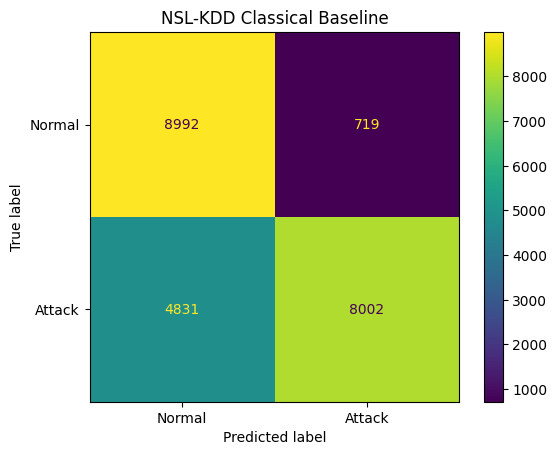

In [22]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Attack"]
)

disp.plot()

plt.title("NSL-KDD Classical Baseline")
plt.show()